In [4]:
# Устанавливаем необходимые библиотеки
!pip install catboost lightgbm xgboost --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.4 MB/s eta 0:00:00


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from catboost import CatBoostClassifier
from tensorflow.keras.datasets import fashion_mnist
import random

# фиксируем random_state
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)



In [17]:
# Загрузка данных
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Размер обучающей выборки:", x_train.shape)
print("Размер тестовой выборки:", x_test.shape)

# нормализация и выравнивание
x_train = x_train.reshape((x_train.shape[0], -1)) / 255.0
x_test = x_test.reshape((x_test.shape[0], -1)) / 255.0

# Преобразуем изображения в плоский вектор
# Многие алгоритмы, например CatBoost, KNN или логистическая регрессия, не умеют работать с матрицами, им нужны плоские векторы признаков.

# уменьшаем выборку для скорости (20k train / 5k test)
x_train_small, _, y_train_small, _ = train_test_split(x_train, y_train, train_size=20000, stratify=y_train, random_state=RANDOM_STATE)
x_test_small, _, y_test_small, _ = train_test_split(x_test, y_test, train_size=5000, stratify=y_test, random_state=RANDOM_STATE)

print("Размер обучающей выборки:", x_train_small.shape)
print("Размер тестовой выборки:", x_test_small.shape)

class_names = ['Футболка/топ', 'Брюки', 'Свитер', 'Платье', 'Пальто',
               'Сандалии', 'Рубашка', 'Кроссовки', 'Сумка', 'Ботильоны']

print(x_train_small.shape, x_test_small.shape)

Размер обучающей выборки: (60000, 28, 28)
Размер тестовой выборки: (10000, 28, 28)
(20000, 784) (5000, 784)


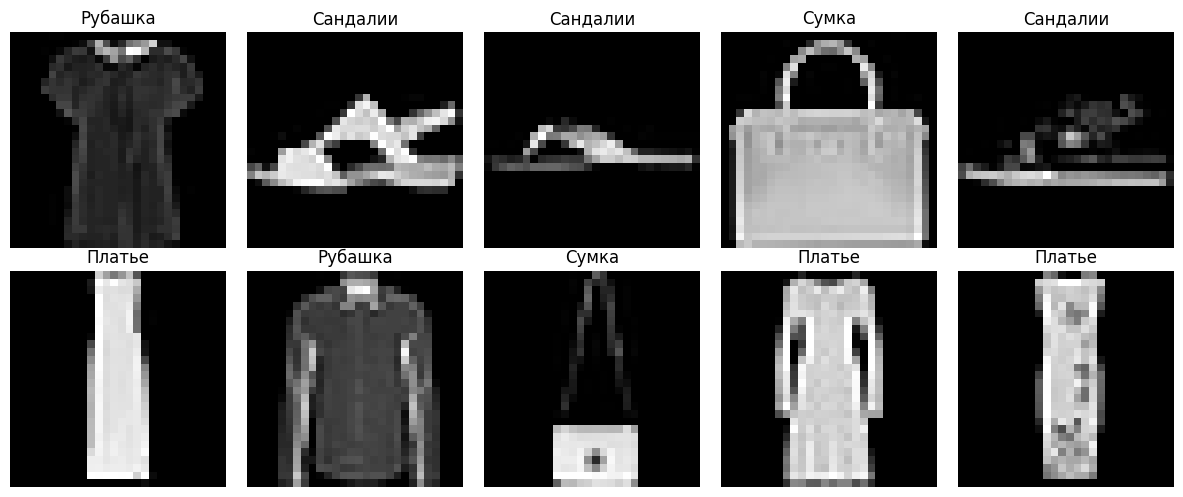

In [18]:
# Примеры картинок
fig, axes = plt.subplots(2, 5, figsize=(12,5))
for i, ax in enumerate(axes.flat):
    idx = np.random.randint(len(x_train_small))
    ax.imshow(x_train_small[idx].reshape(28,28), cmap='gray')
    ax.set_title(class_names[y_train_small[idx]])
    ax.axis('off')
plt.tight_layout()
plt.show()

# Обучение и оценка моделей

## AdaBoost

In [30]:
ada = AdaBoostClassifier(random_state=RANDOM_STATE)
ada.fit(x_train_small, y_train_small)
y_pred_ada = ada.predict(x_test_small)
acc_ada = accuracy_score(y_test_small, y_pred_ada)
print("Accuracy (AdaBoost):", acc_ada)
print(classification_report(y_test_small, y_pred_ada, target_names=class_names))

Accuracy (AdaBoost): 0.4526
              precision    recall  f1-score   support

Футболка/топ       0.75      0.46      0.57       500
       Брюки       0.96      0.76      0.85       500
      Свитер       0.34      0.46      0.39       500
      Платье       0.58      0.72      0.65       500
      Пальто       0.40      0.41      0.41       500
    Сандалии       0.72      0.22      0.33       500
     Рубашка       0.24      0.24      0.24       500
   Кроссовки       0.65      0.14      0.24       500
       Сумка       0.35      0.86      0.49       500
   Ботильоны       0.26      0.26      0.26       500

    accuracy                           0.45      5000
   macro avg       0.53      0.45      0.44      5000
weighted avg       0.53      0.45      0.44      5000



## Extra Trees

In [31]:
et = ExtraTreesClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
et.fit(x_train_small, y_train_small)
y_pred_et = et.predict(x_test_small)
acc_et = accuracy_score(y_test_small, y_pred_et)
print("Accuracy (ExtraTrees):", acc_et)
print(classification_report(y_test_small, y_pred_et, target_names=class_names))

Accuracy (ExtraTrees): 0.8594
              precision    recall  f1-score   support

Футболка/топ       0.79      0.84      0.81       500
       Брюки       1.00      0.94      0.97       500
      Свитер       0.77      0.79      0.78       500
      Платье       0.85      0.89      0.87       500
      Пальто       0.74      0.81      0.77       500
    Сандалии       0.96      0.94      0.95       500
     Рубашка       0.70      0.55      0.62       500
   Кроссовки       0.91      0.92      0.91       500
       Сумка       0.95      0.97      0.96       500
   Ботильоны       0.92      0.94      0.93       500

    accuracy                           0.86      5000
   macro avg       0.86      0.86      0.86      5000
weighted avg       0.86      0.86      0.86      5000



## Logistic Regression

In [19]:
log_reg = LogisticRegression(max_iter=200, random_state=RANDOM_STATE)
log_reg.fit(x_train_small, y_train_small)
y_pred_lr = log_reg.predict(x_test_small)
acc_lr = accuracy_score(y_test_small, y_pred_lr)
print("Accuracy (LogReg):", acc_lr)
print(classification_report(y_test_small, y_pred_lr, target_names=class_names))

Accuracy (LogReg): 0.835
              precision    recall  f1-score   support

Футболка/топ       0.79      0.81      0.80       500
       Брюки       0.97      0.95      0.96       500
      Свитер       0.73      0.70      0.71       500
      Платье       0.83      0.84      0.84       500
      Пальто       0.71      0.75      0.73       500
    Сандалии       0.94      0.92      0.93       500
     Рубашка       0.62      0.58      0.60       500
   Кроссовки       0.91      0.92      0.92       500
       Сумка       0.94      0.95      0.94       500
   Ботильоны       0.92      0.93      0.93       500

    accuracy                           0.83      5000
   macro avg       0.83      0.84      0.83      5000
weighted avg       0.83      0.83      0.83      5000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Random Forest

In [20]:
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(x_train_small, y_train_small)
y_pred_rf = rf.predict(x_test_small)
acc_rf = accuracy_score(y_test_small, y_pred_rf)
print("Accuracy (RandomForest):", acc_rf)
print(classification_report(y_test_small, y_pred_rf, target_names=class_names))

Accuracy (RandomForest): 0.858
              precision    recall  f1-score   support

Футболка/топ       0.80      0.83      0.82       500
       Брюки       1.00      0.94      0.97       500
      Свитер       0.76      0.77      0.77       500
      Платье       0.86      0.90      0.88       500
      Пальто       0.73      0.81      0.77       500
    Сандалии       0.95      0.95      0.95       500
     Рубашка       0.69      0.56      0.62       500
   Кроссовки       0.92      0.92      0.92       500
       Сумка       0.94      0.97      0.95       500
   Ботильоны       0.92      0.93      0.93       500

    accuracy                           0.86      5000
   macro avg       0.86      0.86      0.86      5000
weighted avg       0.86      0.86      0.86      5000



## KNN (с подбором гиперпараметра n_neighbors через GridSearchCV)

In [21]:
param_grid = {'n_neighbors': [3,5,7]}
knn = KNeighborsClassifier()
grid = GridSearchCV(knn, param_grid, cv=3, n_jobs=-1)
grid.fit(x_train_small, y_train_small)
print("Лучший параметр:", grid.best_params_)
knn_best = grid.best_estimator_
y_pred_knn = knn_best.predict(x_test_small)
acc_knn = accuracy_score(y_test_small, y_pred_knn)
print("Accuracy (KNN):", acc_knn)
print(classification_report(y_test_small, y_pred_knn, target_names=class_names))

Лучший параметр: {'n_neighbors': 5}
Accuracy (KNN): 0.8272
              precision    recall  f1-score   support

Футболка/топ       0.75      0.85      0.79       500
       Брюки       0.98      0.94      0.96       500
      Свитер       0.70      0.76      0.73       500
      Платье       0.87      0.84      0.85       500
      Пальто       0.74      0.72      0.73       500
    Сандалии       0.99      0.79      0.88       500
     Рубашка       0.61      0.55      0.58       500
   Кроссовки       0.84      0.93      0.88       500
       Сумка       0.97      0.94      0.96       500
   Ботильоны       0.86      0.96      0.91       500

    accuracy                           0.83      5000
   macro avg       0.83      0.83      0.83      5000
weighted avg       0.83      0.83      0.83      5000



## CatBoost

In [22]:
cat = CatBoostClassifier(iterations=100, depth=6, learning_rate=0.3, verbose=0, random_state=RANDOM_STATE)
cat.fit(x_train_small, y_train_small)
y_pred_cat = cat.predict(x_test_small)
acc_cat = accuracy_score(y_test_small, y_pred_cat)
print("Accuracy (CatBoost):", acc_cat)
print(classification_report(y_test_small, y_pred_cat, target_names=class_names))

Accuracy (CatBoost): 0.8452
              precision    recall  f1-score   support

Футболка/топ       0.80      0.80      0.80       500
       Брюки       0.98      0.95      0.96       500
      Свитер       0.75      0.74      0.75       500
      Платье       0.85      0.89      0.87       500
      Пальто       0.72      0.78      0.75       500
    Сандалии       0.95      0.92      0.93       500
     Рубашка       0.64      0.57      0.60       500
   Кроссовки       0.90      0.91      0.91       500
       Сумка       0.93      0.96      0.95       500
   Ботильоны       0.91      0.94      0.92       500

    accuracy                           0.85      5000
   macro avg       0.84      0.85      0.84      5000
weighted avg       0.84      0.85      0.84      5000



## Сравнение моделей

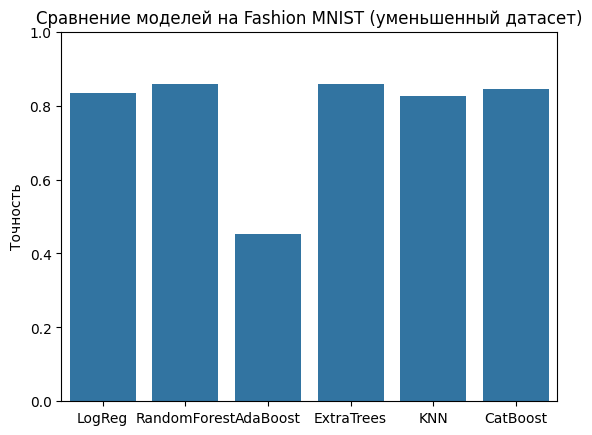

{'LogReg': 0.835,
 'RandomForest': 0.858,
 'AdaBoost': 0.4526,
 'ExtraTrees': 0.8594,
 'KNN': 0.8272,
 'CatBoost': 0.8452}

In [47]:
results = {
    'LogReg': acc_lr,
    'RandomForest': acc_rf,
    'AdaBoost': acc_ada,
    'ExtraTrees': acc_et,
    'KNN': acc_knn,
    'CatBoost': acc_cat
}
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.ylabel('Точность')
plt.ylim(0,1)
plt.title('Сравнение моделей на Fashion MNIST (уменьшенный датасет)')
plt.show()
results

Лучшая модель: ExtraTrees


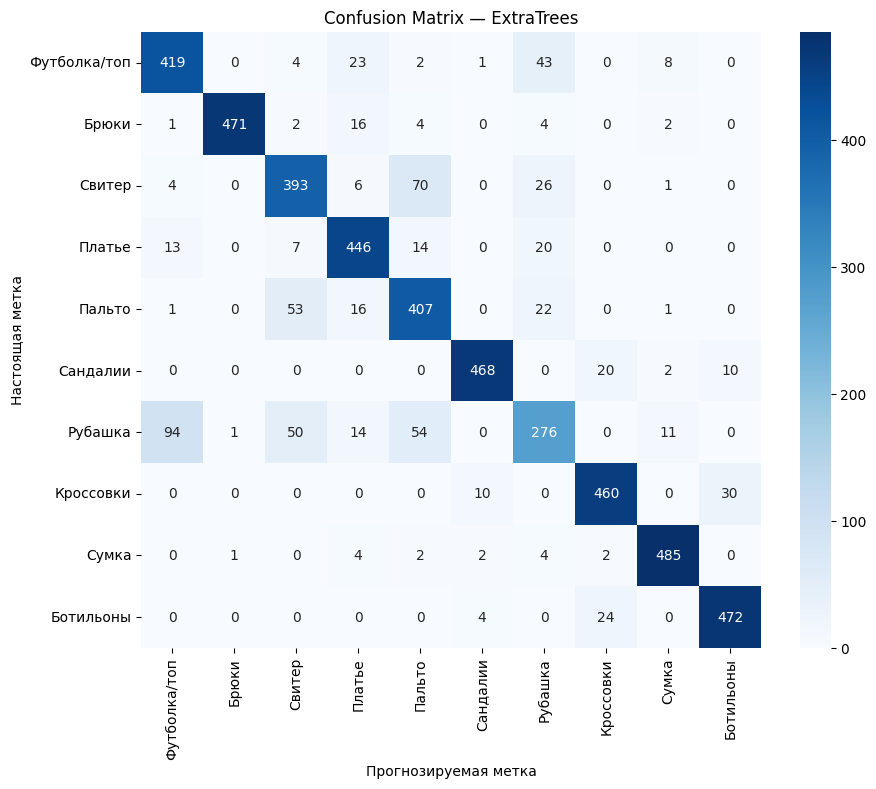

In [41]:
# Матрица ошибок для лучшей модели
best_model_name = max(results, key=results.get)
print("Лучшая модель:", best_model_name)

if best_model_name == 'LogReg':
    y_pred_best = y_pred_lr
elif best_model_name == 'RandomForest':
    y_pred_best = y_pred_rf
elif best_model_name == 'AdaBoost':
    y_pred_best = y_pred_ada
elif best_model_name == 'ExtraTrees':
    y_pred_best = y_pred_et
elif best_model_name == 'KNN':
    y_pred_best = y_pred_knn
else:
    y_pred_best = y_pred_cat

cm = confusion_matrix(y_test_small, y_pred_best)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix — {best_model_name}')
plt.ylabel('Настоящая метка')
plt.xlabel('Прогнозируемая метка')
plt.show()

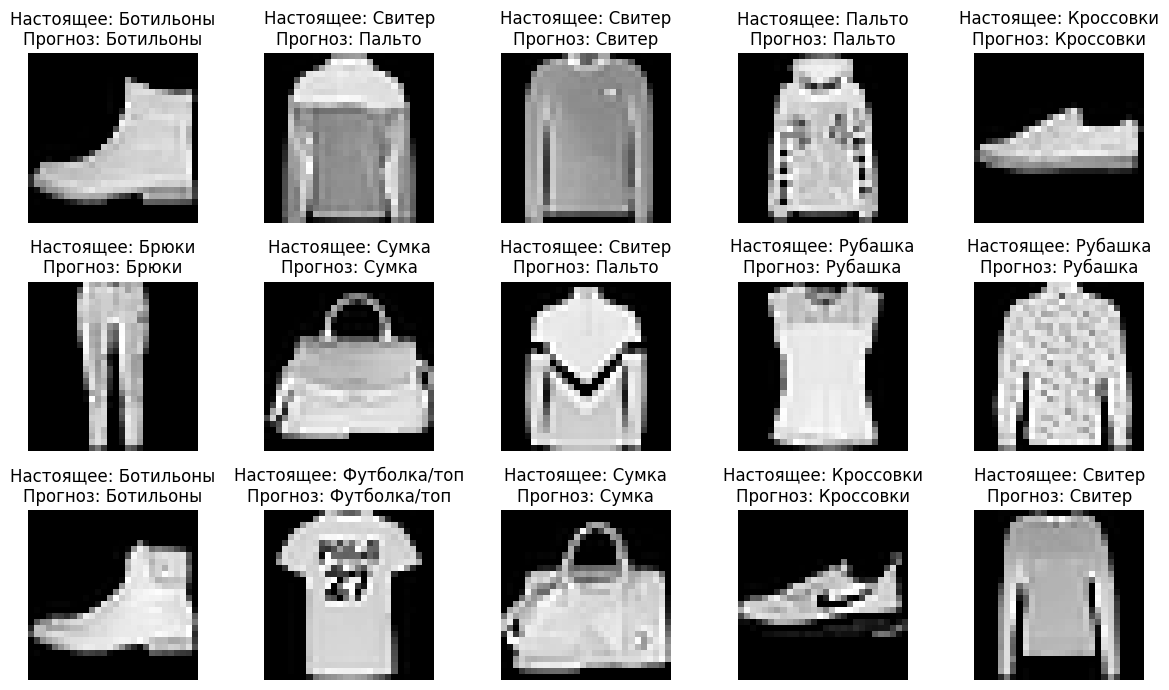

In [43]:
# Примеры изображений с предсказаниями
fig, axes = plt.subplots(3, 5, figsize=(12,7))
for i, ax in enumerate(axes.flat):
    idx = np.random.randint(len(x_test_small))
    ax.imshow(x_test_small[idx].reshape(28,28), cmap='gray')
    ax.set_title(f"Настоящее: {class_names[y_test_small[idx]]}\nПрогноз: {class_names[y_pred_best[idx]]}")
    ax.axis('off')
plt.tight_layout()
plt.show()